In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SIR_models

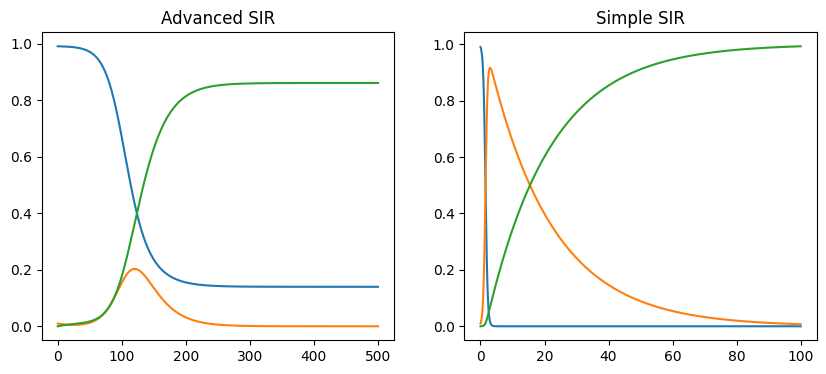

In [3]:
b = 3
g = 0.05

kmax = 100
S = np.zeros(kmax)
I = np.zeros(kmax)
R = np.zeros(kmax)

timespace = np.linspace(0, 500, 10000)


#poisson
lS = 50
lI = 80
sampleS = np.random.poisson(lS, 100000)
sampleI = np.random.poisson(lI, 1000)
for i in range(kmax):
    S[i] = sum(sampleS == i)
    I[i] = sum(sampleI == i)

n = S.sum() + I.sum()

S /= n
I /= n

Slist, Ilist, Rlist = SIR_models.new_model(timespace, S, I, R, b, g)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(timespace, Slist.sum(1), timespace, Ilist.sum(1),timespace, Rlist.sum(1), )
ax1.set_title("Advanced SIR")

S = S.sum()
I = I.sum()
R = R.sum()

timespace = np.linspace(0, 100, 10000)
Slist, Ilist, Rlist = SIR_models.old_model(timespace, S, I, R, b, g)

ax2.plot(timespace, Slist, timespace, Ilist, timespace, Rlist)
ax2.set_title("Simple SIR")
plt.show()


In [24]:
import random
import math
import networkx as nx


def run_epi(graph, b, g, cs0):
    reds = set()
    blues = set(graph.nodes)
    blue_ns = list()
    times = list()
    times.append(0)
    greens = set()
    reds.add(cs0)
    blues.remove(cs0)
    st = [len(blues)]
    it = [1]
    rt = [0]
    #initialization of epidemic
    reds = set()
    blues = set(graph.nodes)
    blue_ns = list()
    times = list()
    times.append(0)
    greens = set()

    reds.add(cs0)
    blues.remove(cs0)
    st = [len(blues)]
    it = [1]
    rt = [0]         

    while True:
        blue_ns = []
        for red in reds:
            for neighbor in graph.neighbors(red):
                if neighbor in blues:
                    blue_ns.append(neighbor)
        ne = len(blue_ns)
        i = len(reds)
        pi = b * ne / (b * ne + i * g)
        pr = g * i / (b * ne + i * g)
        dtime = 1 / (b * ne + i * g) * math.log(1./random.random())
        chance = random.random()

        if chance <= pi:
            new_red = random.choice(blue_ns)
            reds.add(new_red)
            blues.remove(new_red)
            blue_ns.remove(new_red)
        else:
            new_green = random.choice(list(reds))
            reds.remove(new_green)
            greens.add(new_green)
        times.append(times[-1] + dtime)
        st.append(len(blues))
        it.append(len(reds))
        rt.append(len(greens))
        if len(reds) == 0:
            break

    return [np.array(times), np.array(st), np.array(it), np.array(rt)]

In [5]:
def run_aver(graph, b, g, cs0, num=100, divider=1000):
    defres = []
    maxtime = 0

    for i in range(num):
        res = run_epi(graph, b, g, cs0)
        while len(res[0]) < graph.number_of_nodes():
            res = run_epi(graph, b, g, cs0)
        defres.append(res)
        maxtime = max(maxtime, res[0][-1])
            
    abstimes = np.linspace(0, maxtime, divider)

    news = []
    newi = []
    newr = []

    for j in range(num):
        news.append(np.interp(abstimes, defres[j][0], defres[j][1], right = defres[j][1][-1]))
        newi.append(np.interp(abstimes, defres[j][0], defres[j][2], right = defres[j][2][-1]))
        newr.append(np.interp(abstimes, defres[j][0], defres[j][3], right = defres[j][3][-1]))

    avers = np.mean(news, axis = 0)
    averi = np.mean(newi, axis = 0)
    averr = np.mean(newr, axis = 0)
    
    j = divider-1
    while j > 1 and averi[j] < 0.5:
        j -= 1
    
    return(abstimes[:j+1], avers[:j+1], averi[:j+1], averr[:j+1])

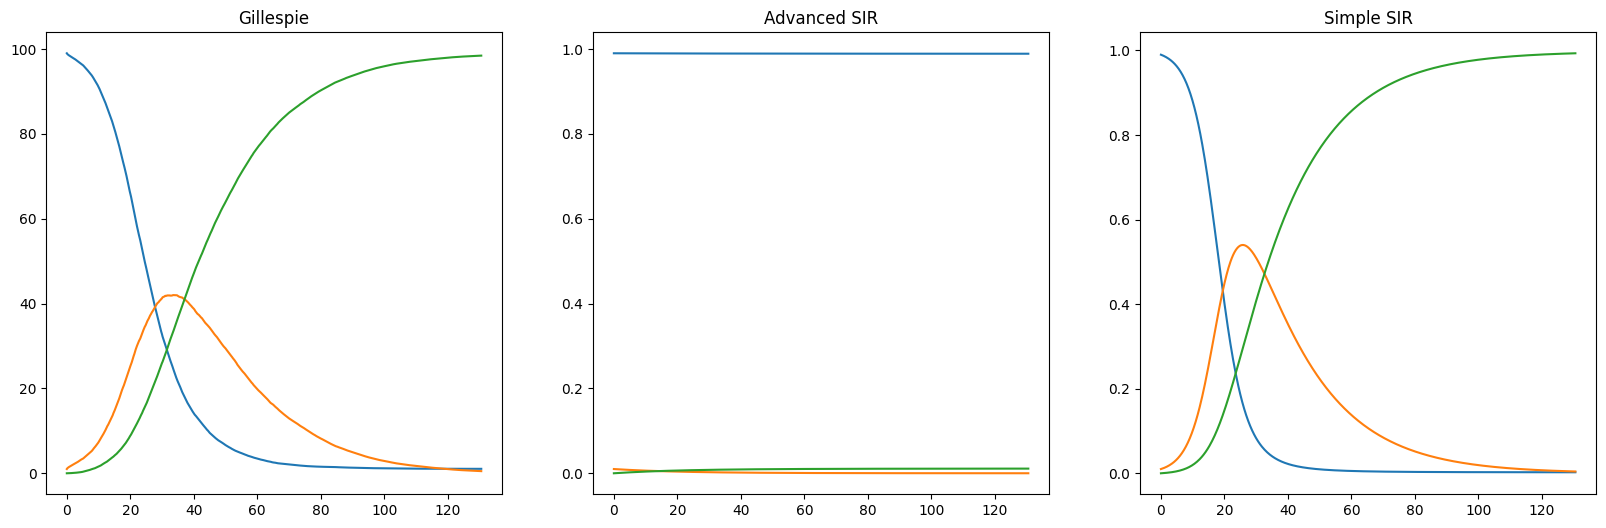

In [23]:
ndots = 100

bo = 0.003
go = 0.05

#net = nx.complete_graph(ndots)
#net = nx.barabasi_albert_graph(n=ndots, m=5)
net = nx.erdos_renyi_graph(n=ndots, p=0.8)
cs0 = list(net.nodes)[0]

t, st, it, rt = run_aver(net, bo, go, cs0, num=200)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(t, st, t, it, t, rt)
ax1.set_title("Gillespie")

b = 0.3
g = 0.05

S = np.zeros(ndots)
I = np.zeros(ndots)
R = np.zeros(ndots)

for node in net.nodes:
    S[nx.degree(net, node)] += 1

S[nx.degree(net, cs0)] -= 1
I[nx.degree(net, cs0)] += 1

n = S.sum() + I.sum()
S /= n
I /= n

Slist, Ilist, Rlist = SIR_models.new_model(t, S, I, R, b, g)

ax2.plot(t, Slist.sum(1), t, Ilist.sum(1), t, Rlist.sum(1))
ax2.set_title("Advanced SIR")

S = S.sum()
I = I.sum()
R = R.sum()

Slist, Ilist, Rlist = SIR_models.old_model(t, S, I, R, b, g)

ax3.plot(t, Slist, t, Ilist, t, Rlist)
ax3.set_title("Simple SIR")
plt.show()

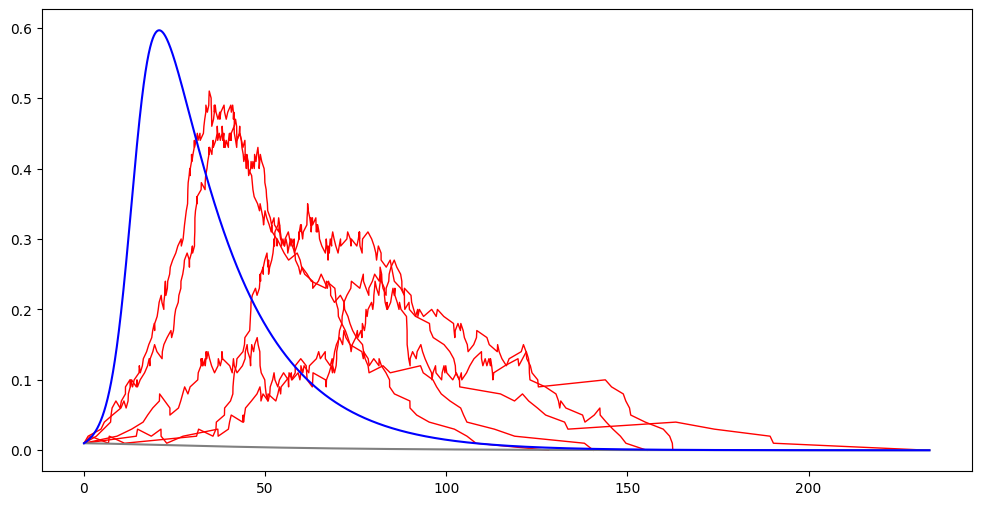

In [81]:
ndots = 100

bo = 0.003
go = 0.05

#net = nx.complete_graph(ndots)
#net = nx.barabasi_albert_graph(n=ndots, m=5)
net = nx.erdos_renyi_graph(n=ndots, p=0.5)
cs0 = list(net.nodes)[0]

plt.figure(figsize=(12, 6))

t_max = 0

for _ in range(5):
    t, st, it, rt = run_epi(net, bo, go, cs0)
    while len(t) < ndots:
        t, st, it, rt = run_epi(net, bo, go, cs0)
    if t_max < t[-1]:
        t_max = t[-1]
    plt.plot(t, it/100, label="I (Gillespie)", color="red", linewidth=1)



b = 0.37
g = 0.05

S = np.zeros(ndots)
I = np.zeros(ndots)
R = np.zeros(ndots)

for node in net.nodes:
    S[nx.degree(net, node)] += 1

S[nx.degree(net, cs0)] -= 1
I[nx.degree(net, cs0)] += 1

n = S.sum() + I.sum()
S /= n
I /= n


t2 = np.linspace(0, t_max, 10000)

Slist, Ilist, Rlist = SIR_models.new_model(t2, S, I, R, b, g)



plt.plot(t2, Ilist.sum(1), label="I (Advanced SIR)", color="grey")

S = S.sum()
I = I.sum()
R = R.sum()

Slist, Ilist, Rlist = SIR_models.old_model(t2, S, I, R, b, g)

plt.plot(t2, Ilist, label="I (Simple SIR)", color="blue")

plt.show()

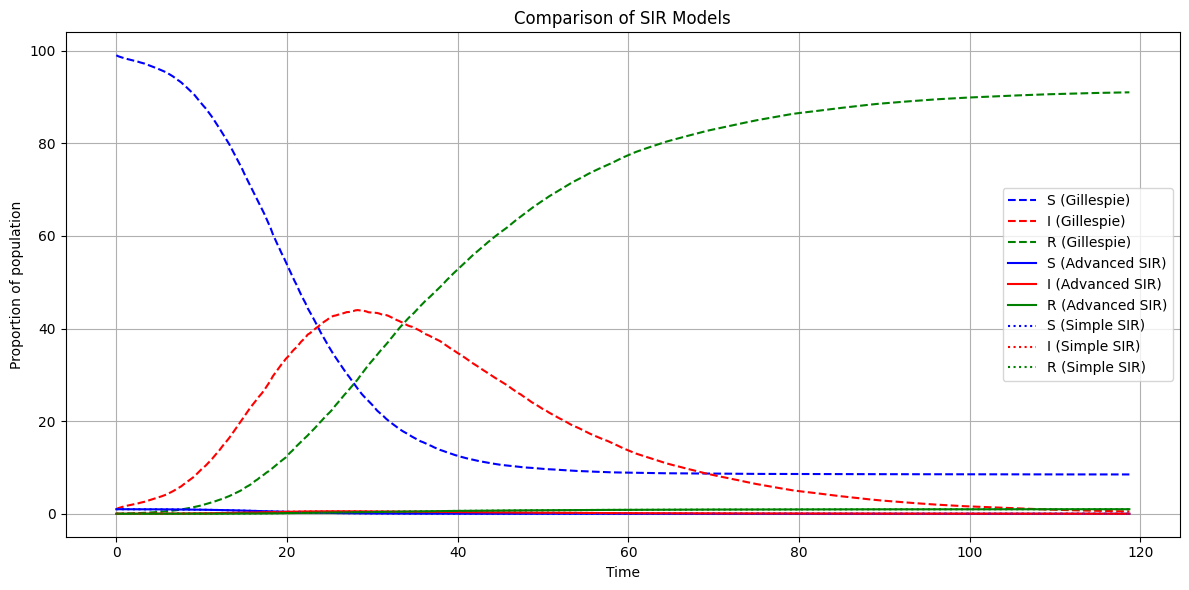

In [238]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Количество узлов
ndots = 100

# Параметры для Gillespie
bo = 0.003
go = 0.05

# Сетка
net = nx.complete_graph(ndots)
# net = nx.barabasi_albert_graph(n=ndots, m=5)
# net = nx.erdos_renyi_graph(n=ndots, p=0.05)
cs0 = list(net.nodes)[0]

# Модель Gillespie (S, I, R)
t, st, it, rt = run_aver(net, bo, go, cs0, num=200)

# Параметры для SIR
b = 0.3
g = 0.05

# Advanced SIR: инициализация
S = np.zeros(ndots)
I = np.zeros(ndots)
R = np.zeros(ndots)

for node in net.nodes:
    S[nx.degree(net, node)] += 1

S[nx.degree(net, cs0)] -= 1
I[nx.degree(net, cs0)] += 1

n = S.sum() + I.sum()
S /= n
I /= n

# Advanced SIR
Slist_adv, Ilist_adv, Rlist_adv = SIR_models.new_model(t, S, I, R, b, g)

# Simple SIR
S0 = S.sum()
I0 = I.sum()
R0 = R.sum()
Slist_simp, Ilist_simp, Rlist_simp = SIR_models.alpha_model(t, S0, I0, R0, b, g, alpha=1)

# Построение одного графика
plt.figure(figsize=(12, 6))

# Gillespie
plt.plot(t, st, label="S (Gillespie)", color="blue", linestyle="--")
plt.plot(t, it, label="I (Gillespie)", color="red", linestyle="--")
plt.plot(t, rt, label="R (Gillespie)", color="green", linestyle="--")

# Advanced SIR
plt.plot(t, Slist_adv.sum(1), label="S (Advanced SIR)", color="blue")
plt.plot(t, Ilist_adv.sum(1), label="I (Advanced SIR)", color="red")
plt.plot(t, Rlist_adv.sum(1), label="R (Advanced SIR)", color="green")

# Simple SIR
plt.plot(t, Slist_simp, label="S (Simple SIR)", color="blue", linestyle=":")
plt.plot(t, Ilist_simp, label="I (Simple SIR)", color="red", linestyle=":")
plt.plot(t, Rlist_simp, label="R (Simple SIR)", color="green", linestyle=":")

plt.xlabel("Time")
plt.ylabel("Proportion of population")
plt.title("Comparison of SIR Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
Slist[-1]

np.float64(nan)

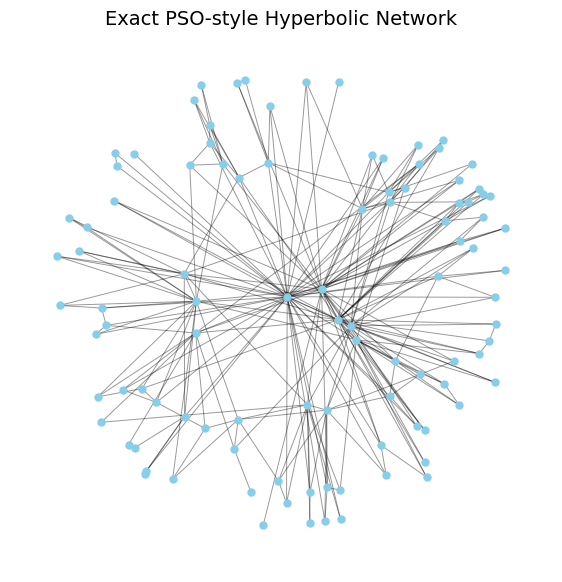

In [214]:
N = 100
m = 3
beta = 0.5
T = 0.5
zeta = 1.0

R = (2 / zeta) * np.log(N / m)

def hyperbolic_dist(ru, rv, theta, phi):
    Δ = np.pi - abs(np.pi - abs(theta - phi))
    return (1 / zeta) * np.arccosh(
        np.cosh(zeta * ru) * np.cosh(zeta * rv) -
        np.sinh(zeta * ru) * np.sinh(zeta * rv) * np.cos(Δ)
    )

def p_conn(d):
    return 1 / (1 + np.exp((d - R) / (T * 2)))

G = nx.Graph()
rs, thetas = [], []
positions = {}


for t in range(1, N + 1):
    r_t = (2 / zeta) * np.log(t)
    theta_t = np.random.uniform(0, 2*np.pi)

    G.add_node(t)
    rs.append(r_t)
    thetas.append(theta_t)
    positions[t] = (r_t * np.cos(theta_t), r_t * np.sin(theta_t))

    # d  to e nodes
    dists = [hyperbolic_dist(r_t, rs[j], theta_t, thetas[j]) for j in range(t - 1)]
    probs = [p_conn(d) for d in dists]

    if t - 1 <= m:
        targets = range(t - 1)
    else:
        idxs = np.arange(t - 1)
        targets = np.random.choice(idxs, size=m, replace=False, p=np.array(probs)/sum(probs))

    for j in targets:
        if np.random.rand() * 0.1 < probs[j]:
            G.add_edge(t, j+1)

plt.figure(figsize=(7,7))
nx.draw_networkx_nodes(G, positions, node_size=25, node_color='skyblue')
nx.draw_networkx_edges(G, positions, alpha=0.4, width=0.7)
plt.title("Exact PSO‑style Hyperbolic Network", fontsize=14)
plt.axis('off')
plt.show()

In [215]:
G.number_of_edges()

262

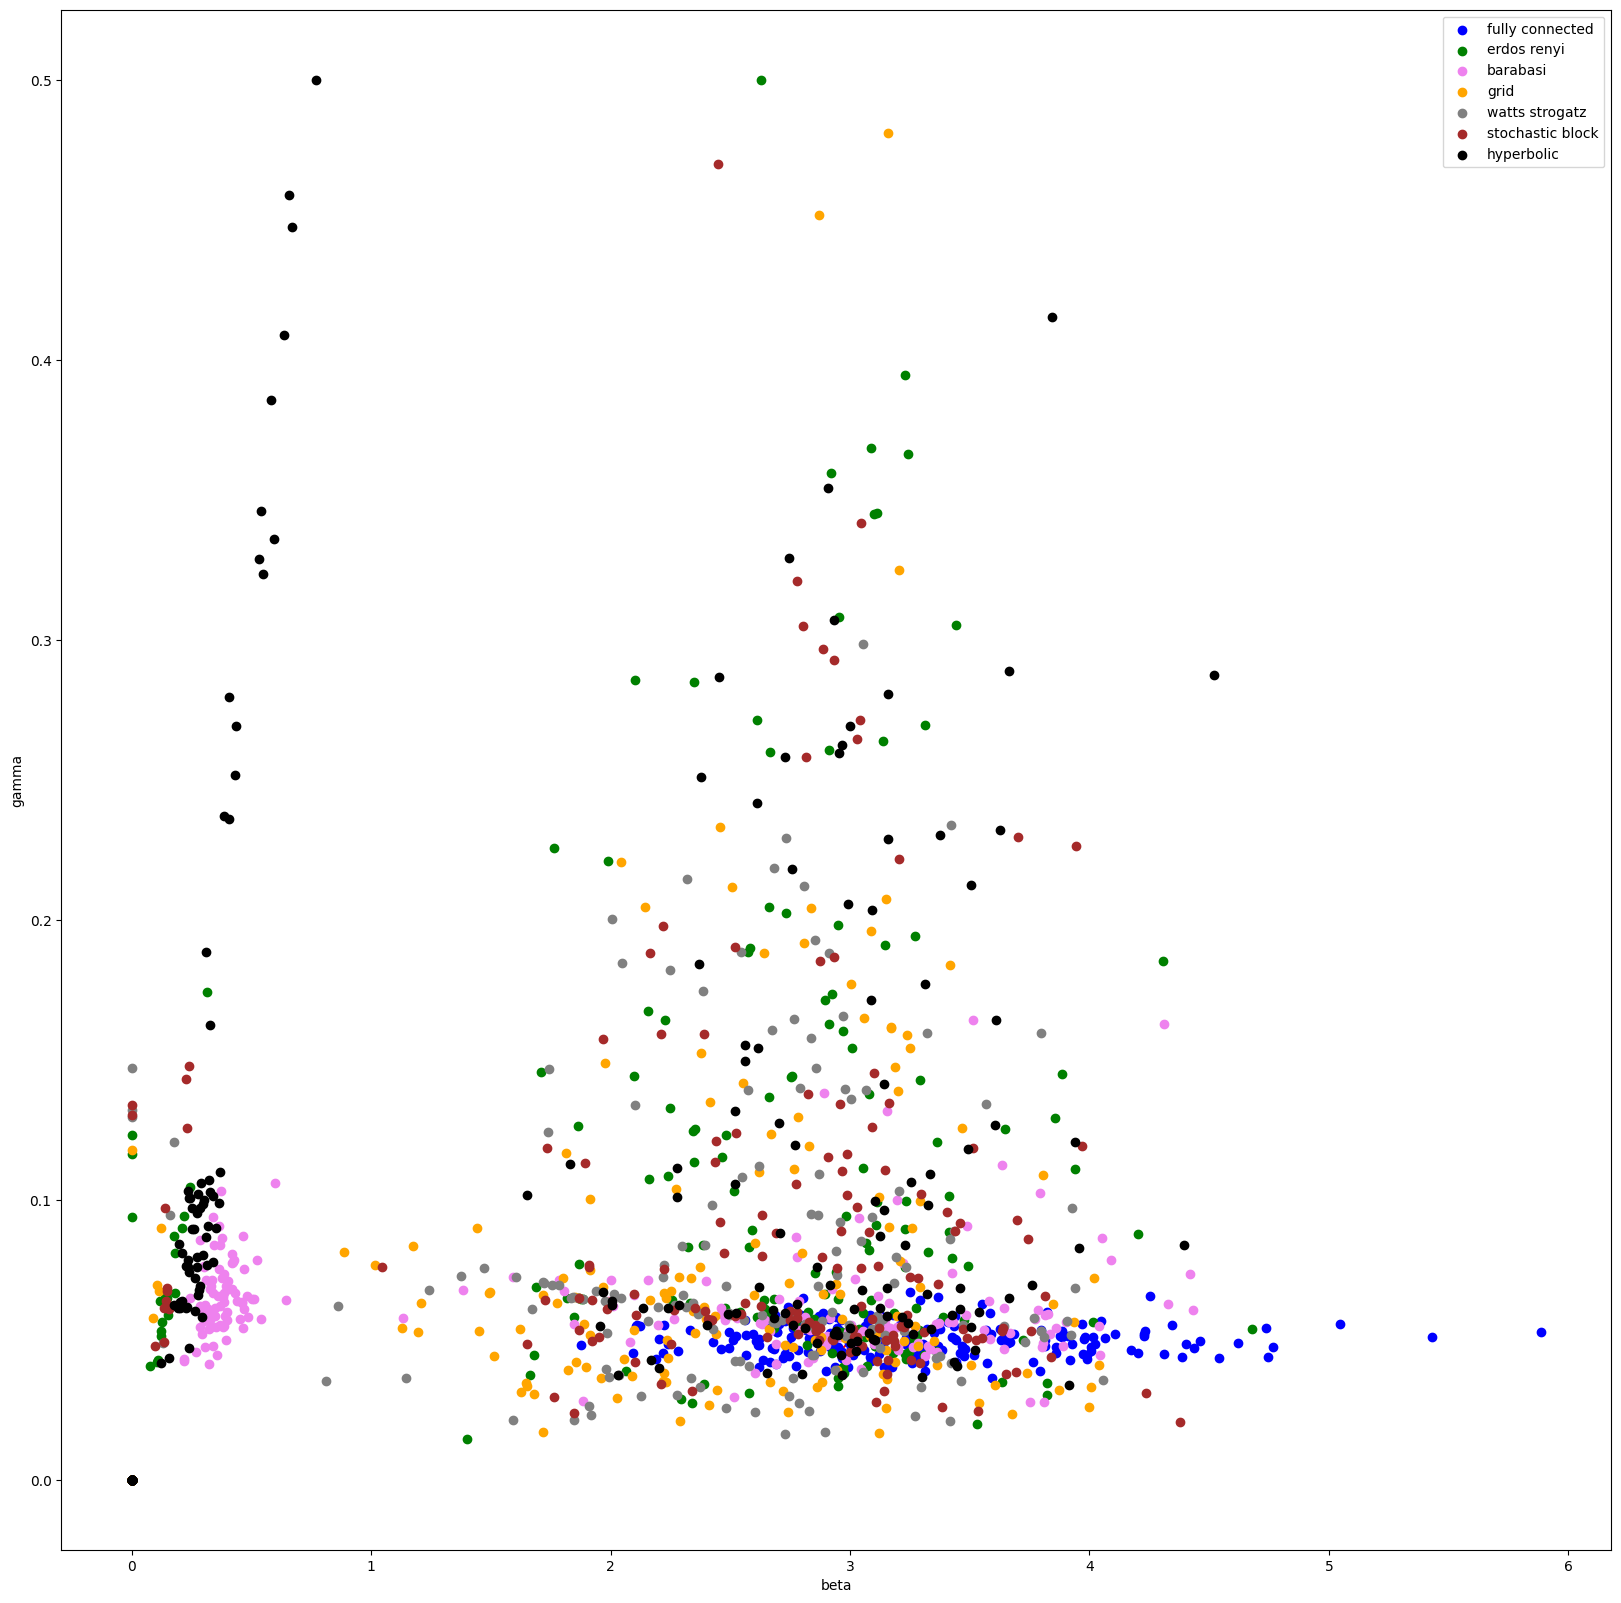

In [237]:
from scipy.optimize import minimize
from scipy.spatial import distance
import networkx as nx

ndots = 100

bo = 0.03
go = 0.05





sizes = [25, 25, 25, 25]
probs = [
    [0.15, 0.01, 0.01, 0.01],
    [0.01, 0.15, 0.01, 0.01],
    [0.01, 0.01, 0.15, 0.01],
    [0.01, 0.01, 0.01, 0.15]
]

nets = [
    nx.complete_graph(ndots),
    nx.erdos_renyi_graph(n=ndots, p=0.05),
    nx.barabasi_albert_graph(n=ndots, m=5),
    nx.grid_2d_graph(10, 10),
    nx.watts_strogatz_graph(n=100, k=5, p=0.3),
    nx.stochastic_block_model(sizes, probs),
    G
]



colors = [
    'blue',
    'green',
    'violet',
    'orange',
    'gray',
    'brown',
    'black'
]

labels = [
    'fully connected',
    'erdos renyi',
    'barabasi',
    'grid',
    'watts strogatz',
    'stochastic block',
    'hyperbolic'
]

#net = nx.stochastic_block_model(sizes, probs)

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
ax.scatter(bo * ndots, go, color='red', marker='x', s=200)

for i in range(len(nets)):
    errors, bos, gos = gen_dots(nets[i], bo, go, 200)
    ax.scatter(bos, gos, color=colors[i], label=labels[i])

plt.xlabel('beta')
plt.ylabel('gamma')
plt.legend()
plt.show()
    

In [231]:
def gen_dots(net, bo, go, num):
    
    n = len(net.nodes)
    
    errors = []
    bos = []
    gos = []

    for _ in range(num):
        
        cs0 = random.choice(list(net.nodes))
        t, st, it, rt = run_epi(net, bo, go, cs0)
        while len(t) < n:
            cs0 = random.choice(list(net.nodes))
            t, st, it, rt = run_epi(net, bo, go, cs0)

        st = st / n
        it = it / n
        rt = rt / n

        def min_func(x):
            Slist, Ilist, Rlist = SIR_models.old_model(t, S, I, R, x[0], x[1])
            dist = distance.euclidean(st, Slist) + distance.euclidean(it, Ilist)
            return dist
    
        res = minimize(min_func, [bo * n, go], bounds=[(0, None),(0.0, 0.5)], method='nelder-mead')

        errors.append(res.fun)
        bos.append(res.x[0])
        gos.append(res.x[1])

    return errors, bos, gos

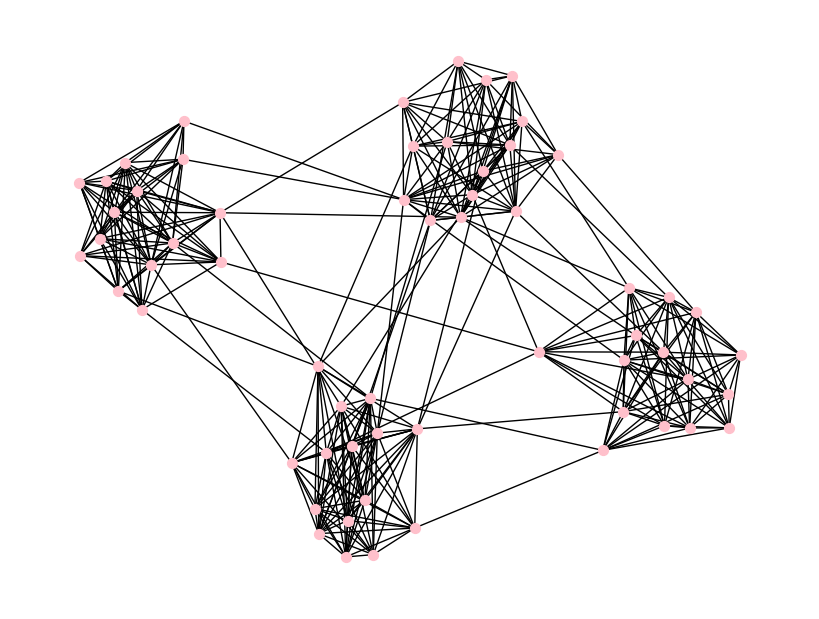

In [33]:
sizes = [15, 15, 15, 15]
probs = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]


K = nx.stochastic_block_model(sizes, probs)
pos = nx.spring_layout(K)
plt.figure(figsize=(8, 6))
nx.draw(K, pos, node_size=50, with_labels=False, node_color='pink')
plt.show()

array([0.01      , 0.01029203, 0.01059249, ..., 0.00729322, 0.00728958,
       0.00728593], shape=(10000,))

In [199]:
min_func([10, 0.06])

np.float64(60.1044)